In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from collections import Counter
import cv2
from skimage import exposure, filters
import warnings
warnings.filterwarnings('ignore')

print("All imports OK")

All imports OK


In [2]:
# Paths
BASE_DIR = Path("../data/solar_thermal")
IMG_DIR = BASE_DIR / "images"
META_PATH = BASE_DIR / "module_metadata.json"

# Load metadata
with open(META_PATH, "r") as f:
    metadata = json.load(f)

# Convert to DataFrame
records = []
for img_id, info in metadata.items():
    records.append({
        "image_id": img_id,
        "filepath": BASE_DIR / info["image_filepath"],
        "anomaly_class": info["anomaly_class"]
    })

df = pd.DataFrame(records)

# Class distribution
class_counts = df["anomaly_class"].value_counts()

print(f"Total images: {len(df)}")
print(f"Total classes: {df['anomaly_class'].nunique()}")
print(f"\nClass distribution:")
print(class_counts.to_string())

Total images: 20000
Total classes: 12

Class distribution:
anomaly_class
No-Anomaly        10000
Cell               1877
Vegetation         1639
Diode              1499
Cell-Multi         1288
Shadowing          1056
Cracking            940
Offline-Module      827
Hot-Spot            249
Hot-Spot-Multi      246
Soiling             204
Diode-Multi         175


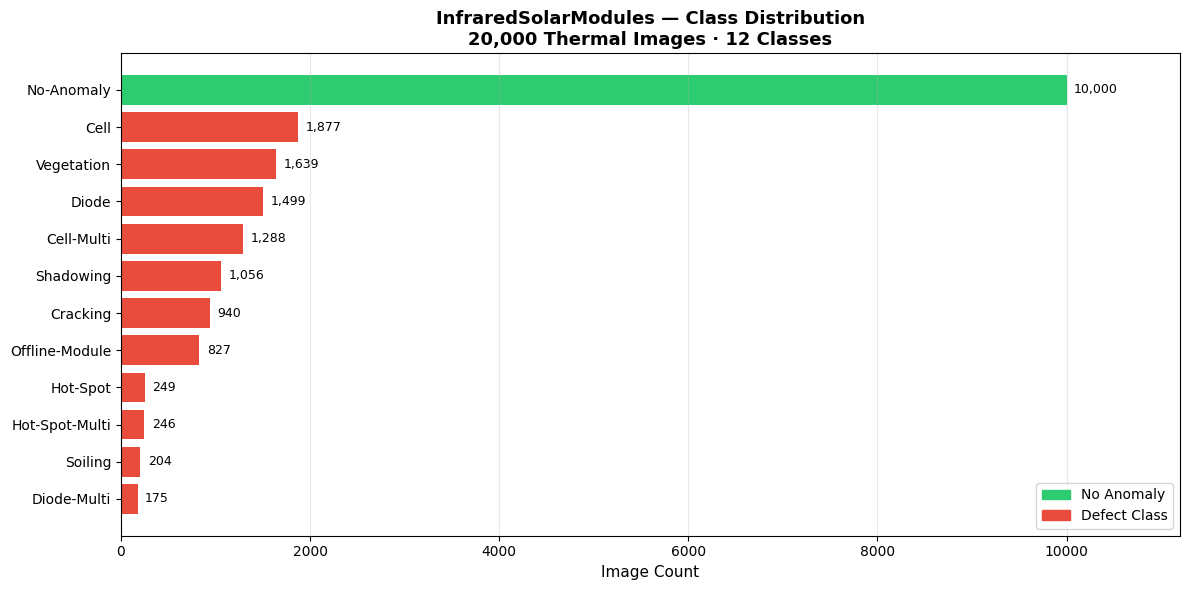

Chart saved.


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#2ecc71" if c == "No-Anomaly" else "#e74c3c" for c in class_counts.index]

bars = ax.barh(class_counts.index, class_counts.values, color=colors)

# Value labels
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)

ax.set_xlabel("Image Count", fontsize=11)
ax.set_title("InfraredSolarModules — Class Distribution\n20,000 Thermal Images · 12 Classes", 
             fontsize=13, fontweight="bold")

healthy_patch = mpatches.Patch(color="#2ecc71", label="No Anomaly")
defect_patch  = mpatches.Patch(color="#e74c3c", label="Defect Class")
ax.legend(handles=[healthy_patch, defect_patch], loc="lower right")

ax.set_xlim(0, class_counts.max() + 1200)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/sprint05a_class_distribution.png", dpi=150)
plt.show()
print("Chart saved.")

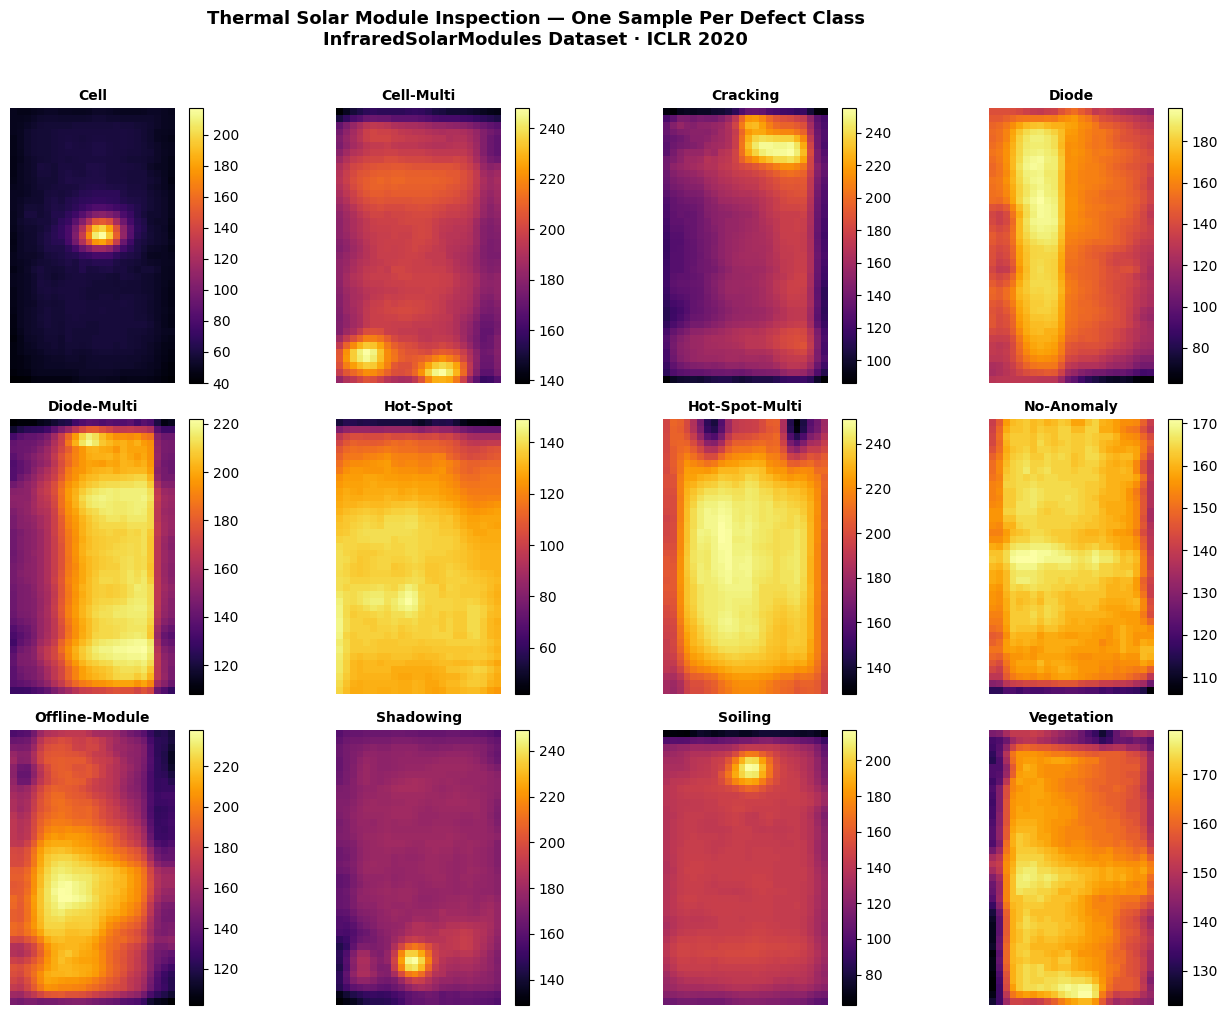

Sample grid saved.


In [5]:
# Pick one sample image per class
samples = df.groupby("anomaly_class").first().reset_index()

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for idx, row in samples.iterrows():
    img = Image.open(row["filepath"]).convert("L")  # grayscale thermal
    img_array = np.array(img)

    ax = axes[idx]
    im = ax.imshow(img_array, cmap="inferno")
    ax.set_title(row["anomaly_class"], fontsize=10, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Thermal Solar Module Inspection — One Sample Per Defect Class\nInfraredSolarModules Dataset · ICLR 2020",
             fontsize=13, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("../outputs/sprint05a_class_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample grid saved.")

In [6]:
def analyze_thermal(filepath):
    """Extract thermal statistics from a single module image."""
    img = np.array(Image.open(filepath).convert("L")).astype(np.float32)
    
    total_pixels = img.size
    mean_temp    = img.mean()
    max_temp     = img.max()
    min_temp     = img.min()
    std_temp     = img.std()
    
    # Hotspot = pixels above 90th percentile
    threshold    = np.percentile(img, 90)
    hotspot_mask = img >= threshold
    hotspot_pct  = (hotspot_mask.sum() / total_pixels) * 100
    
    # Thermal gradient — how uneven is the temperature distribution
    gradient = np.gradient(img)
    grad_magnitude = np.sqrt(gradient[0]**2 + gradient[1]**2).mean()
    
    return {
        "mean_temp": mean_temp,
        "max_temp": max_temp,
        "min_temp": min_temp,
        "std_temp": std_temp,
        "hotspot_pct": hotspot_pct,
        "thermal_gradient": grad_magnitude
    }

# Run analysis on all 20,000 images
print("Analyzing all images — this may take ~1 minute...")

results = []
for _, row in df.iterrows():
    stats = analyze_thermal(row["filepath"])
    stats["anomaly_class"] = row["anomaly_class"]
    results.append(stats)

df_stats = pd.DataFrame(results)

print(f"Done. Shape: {df_stats.shape}")
print(df_stats.groupby("anomaly_class")[["mean_temp", "hotspot_pct", "thermal_gradient"]].mean().round(2))

Analyzing all images — this may take ~1 minute...
Done. Shape: (20000, 7)
                 mean_temp  hotspot_pct  thermal_gradient
anomaly_class                                            
Cell            156.720001        11.20              5.95
Cell-Multi      167.759995        10.77              7.06
Cracking        166.910004        10.38              8.61
Diode           168.509995        10.82              6.82
Diode-Multi     177.300003        11.14              8.33
Hot-Spot        164.649994        11.51              5.12
Hot-Spot-Multi  183.649994        11.30              6.15
No-Anomaly      150.899994        11.96              4.90
Offline-Module  173.199997        11.59              6.88
Shadowing       148.750000        11.46              4.47
Soiling         170.270004        10.99              6.11
Vegetation      168.860001        11.25              6.61


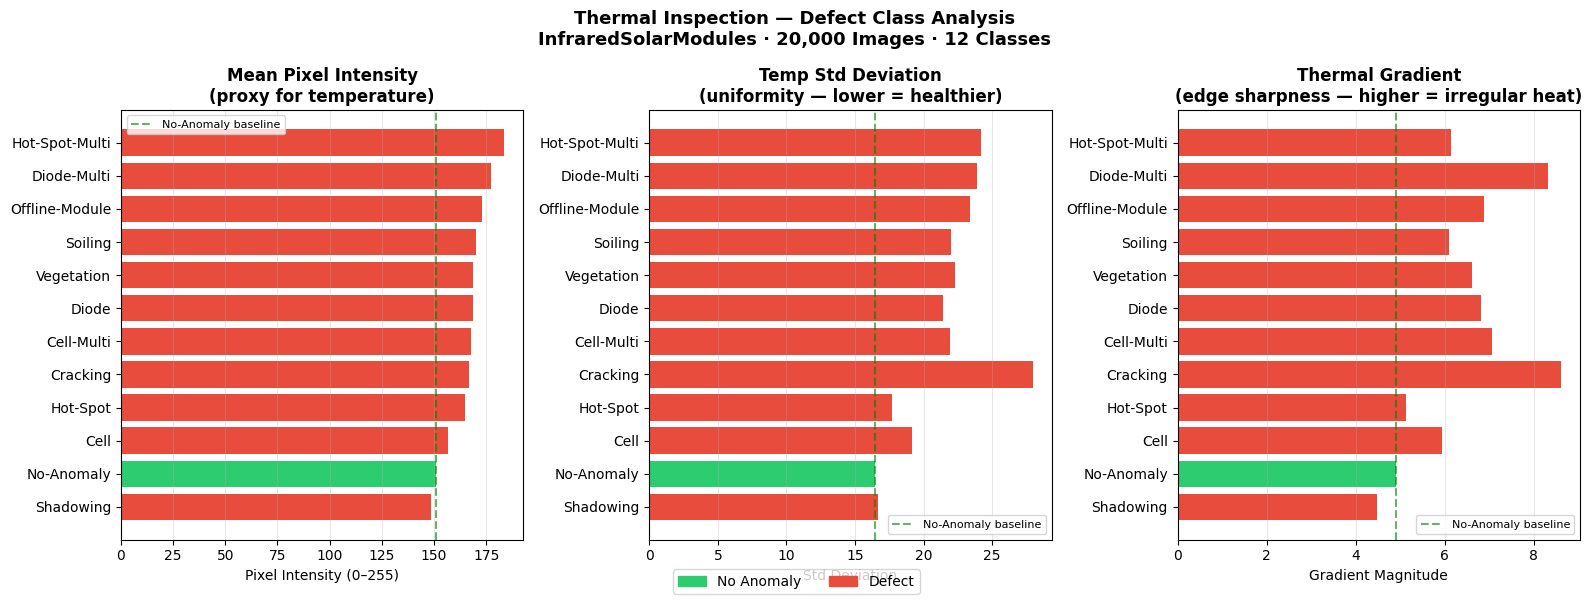

Analysis chart saved.


In [7]:
# Aggregate stats per class
summary = df_stats.groupby("anomaly_class").agg(
    mean_temp=("mean_temp", "mean"),
    std_temp=("std_temp", "mean"),
    thermal_gradient=("thermal_gradient", "mean")
).reset_index().sort_values("mean_temp", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

colors = ["#2ecc71" if c == "No-Anomaly" else "#e74c3c" for c in summary["anomaly_class"]]

# Panel 1 — Mean temperature
axes[0].barh(summary["anomaly_class"], summary["mean_temp"], color=colors)
axes[0].set_title("Mean Pixel Intensity\n(proxy for temperature)", fontweight="bold")
axes[0].set_xlabel("Pixel Intensity (0–255)")
axes[0].axvline(summary[summary["anomaly_class"] == "No-Anomaly"]["mean_temp"].values[0],
                color="green", linestyle="--", alpha=0.6, label="No-Anomaly baseline")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

# Panel 2 — Std deviation (temperature uniformity)
axes[1].barh(summary["anomaly_class"], summary["std_temp"], color=colors)
axes[1].set_title("Temp Std Deviation\n(uniformity — lower = healthier)", fontweight="bold")
axes[1].set_xlabel("Std Deviation")
axes[1].axvline(summary[summary["anomaly_class"] == "No-Anomaly"]["std_temp"].values[0],
                color="green", linestyle="--", alpha=0.6, label="No-Anomaly baseline")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

# Panel 3 — Thermal gradient
axes[2].barh(summary["anomaly_class"], summary["thermal_gradient"], color=colors)
axes[2].set_title("Thermal Gradient\n(edge sharpness — higher = irregular heat)", fontweight="bold")
axes[2].set_xlabel("Gradient Magnitude")
axes[2].axvline(summary[summary["anomaly_class"] == "No-Anomaly"]["thermal_gradient"].values[0],
                color="green", linestyle="--", alpha=0.6, label="No-Anomaly baseline")
axes[2].legend(fontsize=8)
axes[2].grid(axis="x", alpha=0.3)

fig.suptitle("Thermal Inspection — Defect Class Analysis\nInfraredSolarModules · 20,000 Images · 12 Classes",
             fontsize=13, fontweight="bold")

healthy_patch = mpatches.Patch(color="#2ecc71", label="No Anomaly")
defect_patch  = mpatches.Patch(color="#e74c3c", label="Defect")
fig.legend(handles=[healthy_patch, defect_patch], loc="lower center", ncol=2, fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/sprint05a_thermal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Analysis chart saved.")

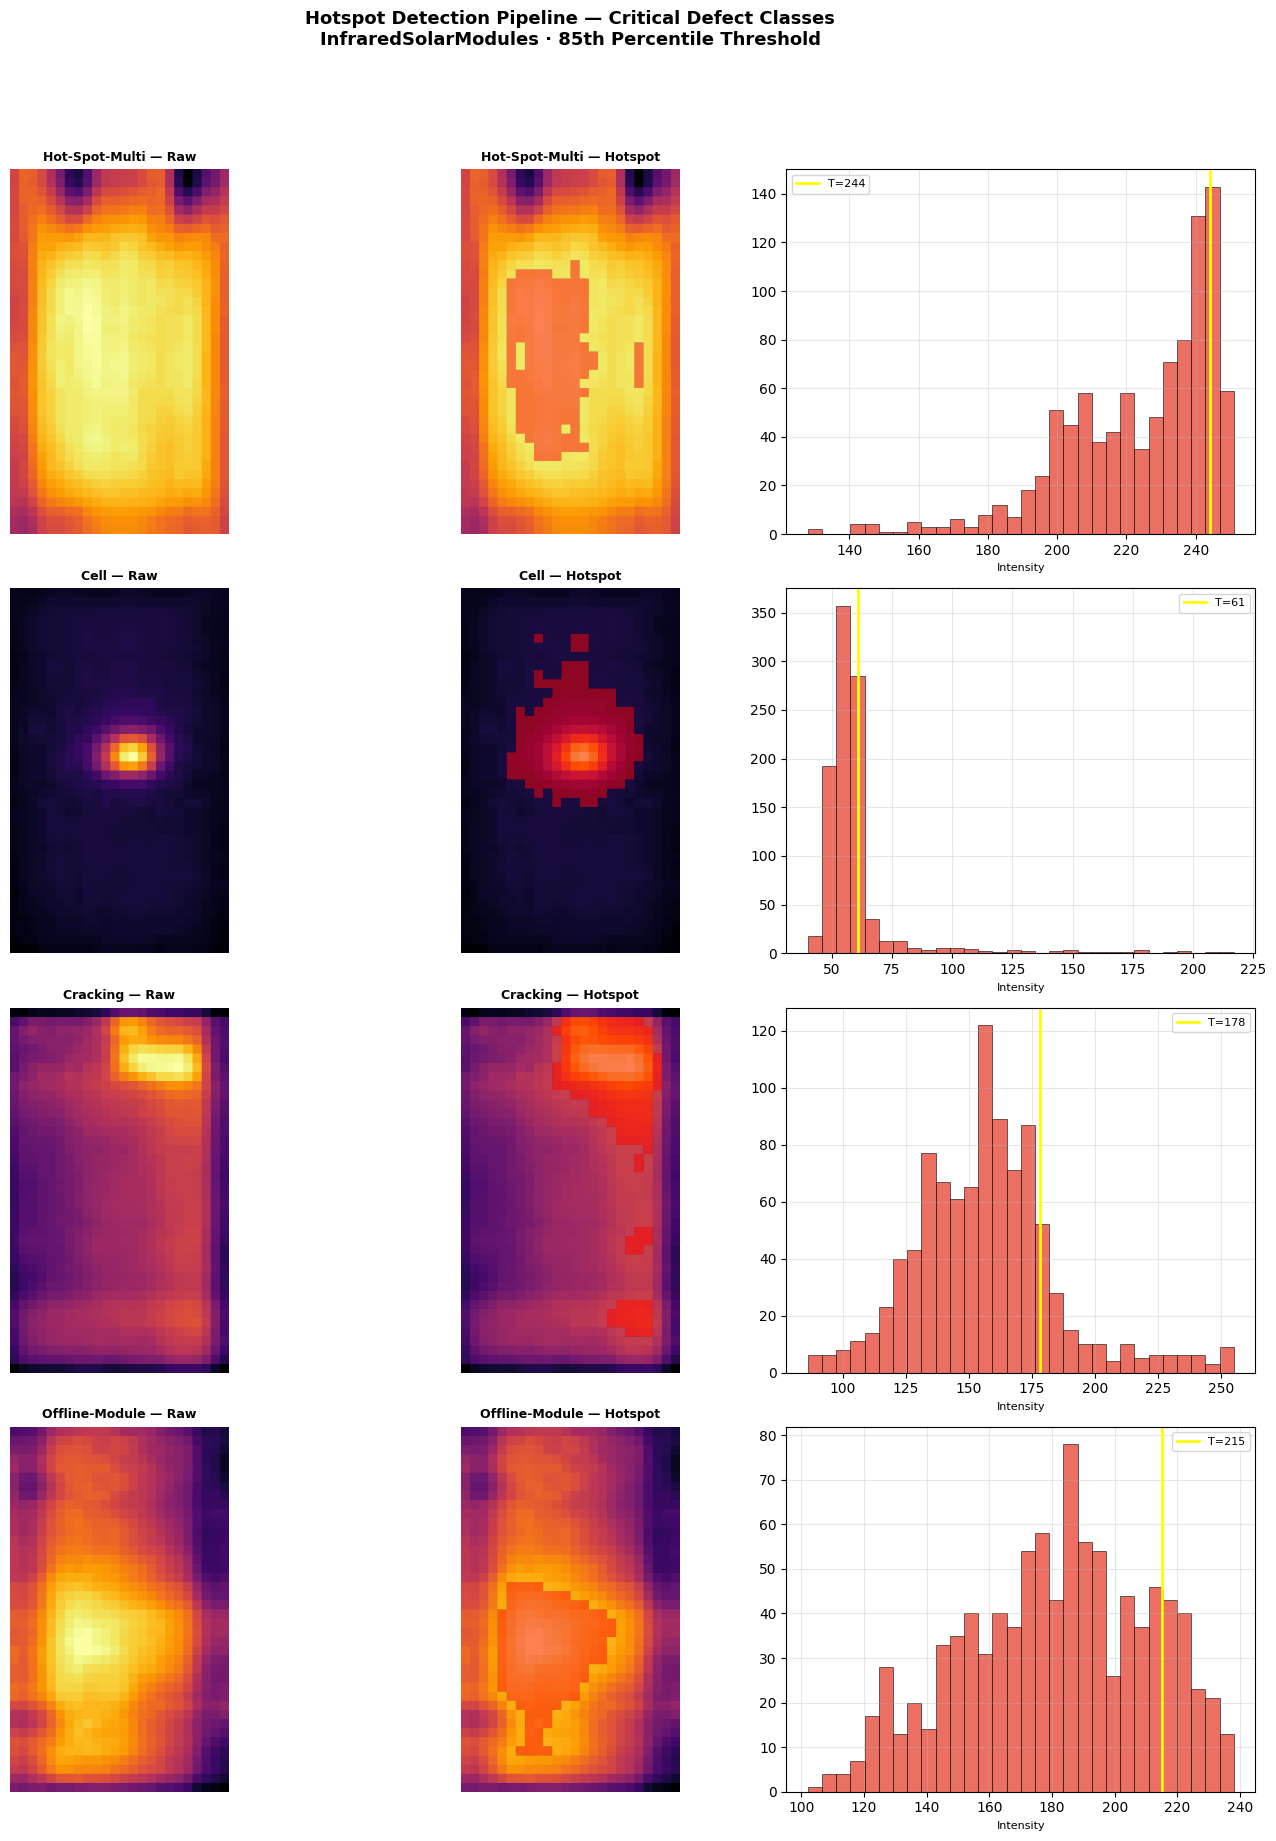

Hotspot detection chart saved.


In [10]:
def plot_hotspot_detection(anomaly_class, threshold_pct=85):
    """Show thermal image + hotspot overlay for a given class."""
    sample = df[df["anomaly_class"] == anomaly_class].iloc[0]
    img = np.array(Image.open(sample["filepath"]).convert("L")).astype(np.float32)
    
    # Threshold
    threshold = np.percentile(img, threshold_pct)
    hotspot_mask = img >= threshold
    
    # Upscale for visibility (24x40 is tiny)
    scale = 8
    img_large = cv2.resize(img, (img.shape[1]*scale, img.shape[0]*scale), 
                           interpolation=cv2.INTER_NEAREST)
    mask_large = cv2.resize(hotspot_mask.astype(np.uint8), 
                            (img.shape[1]*scale, img.shape[0]*scale),
                            interpolation=cv2.INTER_NEAREST)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Raw thermal
    axes[0].imshow(img_large, cmap="inferno")
    axes[0].set_title("Raw Thermal Image", fontweight="bold")
    axes[0].axis("off")
    
    # Hotspot mask
    axes[1].imshow(img_large, cmap="inferno")
    overlay = np.zeros((*img_large.shape, 4))
    overlay[mask_large == 1] = [1, 0, 0, 0.5]  # red overlay
    axes[1].imshow(overlay)
    axes[1].set_title(f"Hotspot Detection\n(>{threshold_pct}th percentile)", fontweight="bold")
    axes[1].axis("off")
    
    # Temperature histogram
    axes[2].hist(img.flatten(), bins=30, color="#e74c3c", alpha=0.8, edgecolor="black", linewidth=0.5)
    axes[2].axvline(threshold, color="yellow", linewidth=2, label=f"Threshold ({threshold:.0f})")
    axes[2].set_title("Pixel Intensity Distribution", fontweight="bold")
    axes[2].set_xlabel("Intensity (proxy: temperature)")
    axes[2].set_ylabel("Pixel count")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    fig.suptitle(f"Hotspot Detection — Class: {anomaly_class}", 
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig

# Run for the most critical defect classes
critical_classes = ["Hot-Spot-Multi", "Cell", "Cracking", "Offline-Module"]

figs = []
for cls in critical_classes:
    fig = plot_hotspot_detection(cls)
    figs.append(fig)

# Save as combined figure
fig_combined, axes_combined = plt.subplots(4, 3, figsize=(14, 18))

for i, (cls, fig) in enumerate(zip(critical_classes, figs)):
    plt.close(fig)

# Re-render combined
for i, cls in enumerate(critical_classes):
    sample = df[df["anomaly_class"] == cls].iloc[0]
    img = np.array(Image.open(sample["filepath"]).convert("L")).astype(np.float32)
    threshold = np.percentile(img, 85)
    hotspot_mask = img >= threshold
    scale = 8
    img_large = cv2.resize(img, (img.shape[1]*scale, img.shape[0]*scale),
                           interpolation=cv2.INTER_NEAREST)
    mask_large = cv2.resize(hotspot_mask.astype(np.uint8),
                            (img.shape[1]*scale, img.shape[0]*scale),
                            interpolation=cv2.INTER_NEAREST)

    axes_combined[i][0].imshow(img_large, cmap="inferno")
    axes_combined[i][0].set_title(f"{cls} — Raw", fontweight="bold", fontsize=9)
    axes_combined[i][0].axis("off")

    axes_combined[i][1].imshow(img_large, cmap="inferno")
    overlay = np.zeros((*img_large.shape, 4))
    overlay[mask_large == 1] = [1, 0, 0, 0.5]
    axes_combined[i][1].imshow(overlay)
    axes_combined[i][1].set_title(f"{cls} — Hotspot", fontweight="bold", fontsize=9)
    axes_combined[i][1].axis("off")

    axes_combined[i][2].hist(img.flatten(), bins=30, color="#e74c3c", alpha=0.8,
                              edgecolor="black", linewidth=0.5)
    axes_combined[i][2].axvline(threshold, color="yellow", linewidth=2,
                                 label=f"T={threshold:.0f}")
    axes_combined[i][2].set_xlabel("Intensity", fontsize=8)
    axes_combined[i][2].legend(fontsize=8)
    axes_combined[i][2].grid(alpha=0.3)

fig_combined.suptitle("Hotspot Detection Pipeline — Critical Defect Classes\nInfraredSolarModules · 85th Percentile Threshold",
                       fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("../outputs/sprint05a_hotspot_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Hotspot detection chart saved.")

In [11]:
# Full statistical summary per class
summary_full = df_stats.groupby("anomaly_class").agg(
    count=("mean_temp", "count"),
    mean_temp=("mean_temp", "mean"),
    max_temp=("max_temp", "mean"),
    std_temp=("std_temp", "mean"),
    hotspot_pct=("hotspot_pct", "mean"),
    thermal_gradient=("thermal_gradient", "mean")
).reset_index().sort_values("mean_temp", ascending=False)

summary_full = summary_full.round(3)

print("=" * 75)
print("SPRINT 05A — SOLAR THERMAL INSPECTION SUMMARY")
print("Dataset: InfraredSolarModules · ICLR 2020 · 20,000 images · 12 classes")
print("=" * 75)
print(summary_full.to_string(index=False))
print("=" * 75)

# Key findings
baseline = summary_full[summary_full["anomaly_class"] == "No-Anomaly"].iloc[0]
hottest  = summary_full.iloc[0]
highest_grad = summary_full.loc[summary_full["thermal_gradient"].idxmax()]

print("\nKEY FINDINGS:")
print(f"  → Hottest defect class    : {hottest['anomaly_class']} (mean intensity {hottest['mean_temp']:.1f})")
print(f"  → No-Anomaly baseline     : mean intensity {baseline['mean_temp']:.1f}")
print(f"  → Delta hottest vs healthy: +{hottest['mean_temp'] - baseline['mean_temp']:.1f} intensity units")
print(f"  → Highest thermal gradient: {highest_grad['anomaly_class']} ({highest_grad['thermal_gradient']:.2f}) — most irregular heat")
print(f"  → Total defective images  : {len(df[df['anomaly_class'] != 'No-Anomaly']):,} / {len(df):,} ({len(df[df['anomaly_class'] != 'No-Anomaly'])/len(df)*100:.1f}%)")

SPRINT 05A — SOLAR THERMAL INSPECTION SUMMARY
Dataset: InfraredSolarModules · ICLR 2020 · 20,000 images · 12 classes
 anomaly_class  count  mean_temp   max_temp  std_temp  hotspot_pct  thermal_gradient
Hot-Spot-Multi    246 183.645996 222.667007 24.205999       11.299             6.152
   Diode-Multi    175 177.298996 216.399994 23.865000       11.142             8.326
Offline-Module    827 173.199005 205.863007 23.379999       11.594             6.879
       Soiling    204 170.274002 241.373001 21.993999       10.991             6.106
    Vegetation   1639 168.860001 226.947006 22.287001       11.249             6.611
         Diode   1499 168.507996 207.440002 21.393999       10.822             6.824
    Cell-Multi   1288 167.764999 229.317993 21.941000       10.770             7.059
      Cracking    940 166.906006 243.559006 27.945000       10.379             8.611
      Hot-Spot    249 164.649994 196.763000 17.664000       11.515             5.123
          Cell   1877 156.723007 

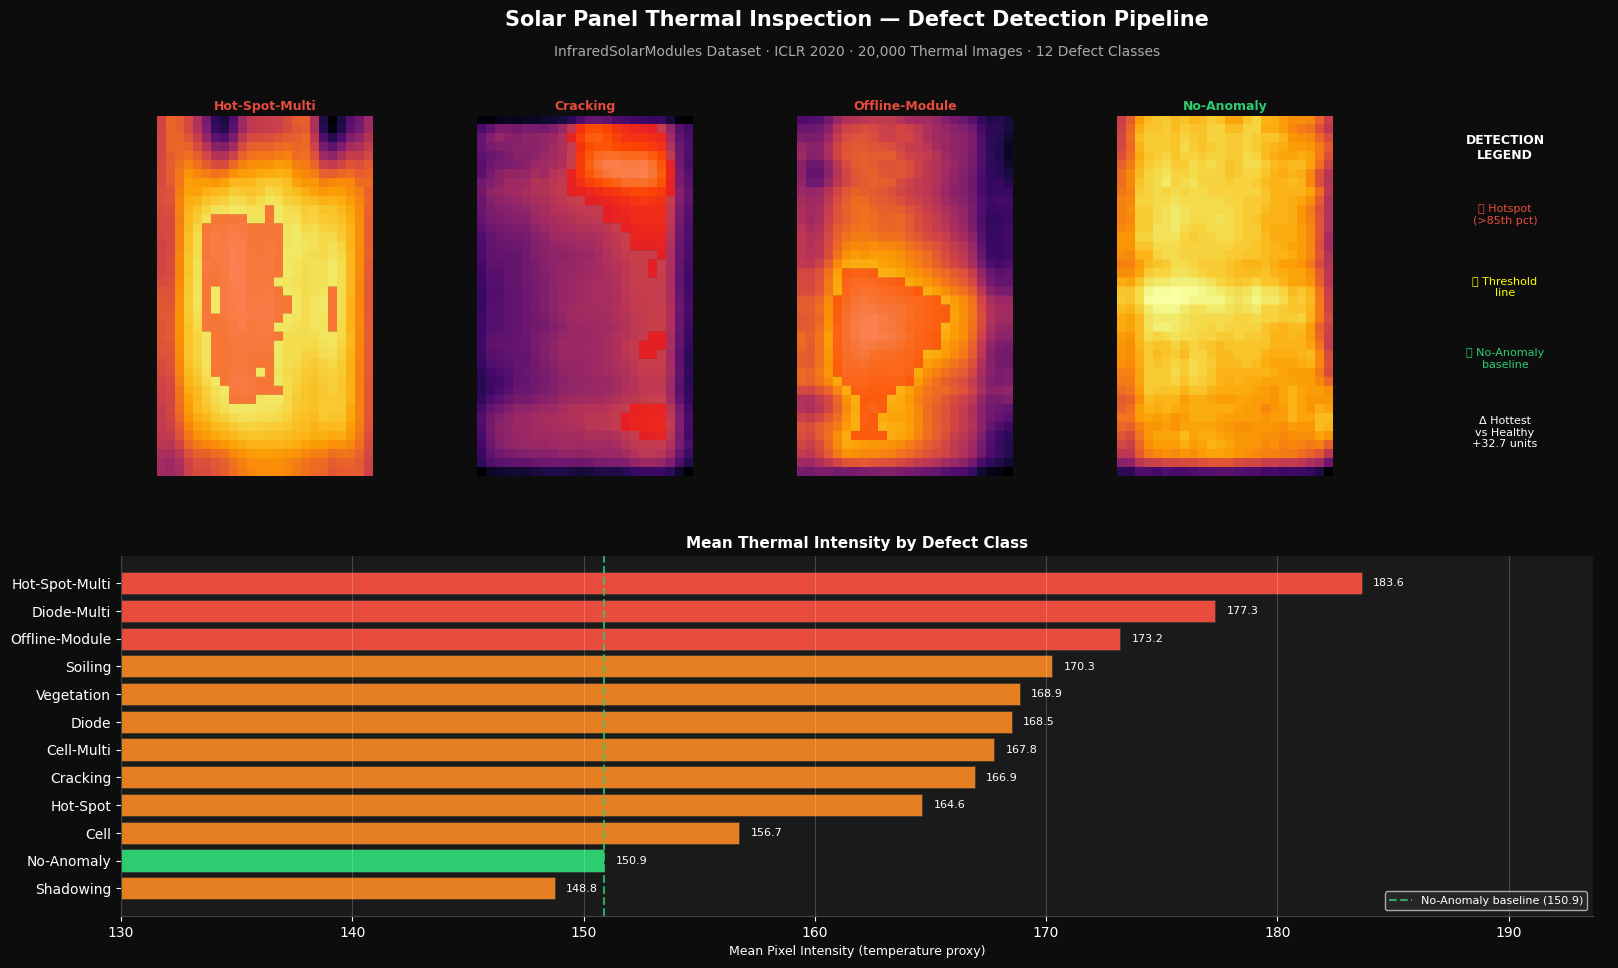

Final map saved.


In [12]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#0d0d0d")

# Title
fig.text(0.5, 0.97, "Solar Panel Thermal Inspection — Defect Detection Pipeline",
         ha="center", fontsize=15, fontweight="bold", color="white")
fig.text(0.5, 0.94, "InfraredSolarModules Dataset · ICLR 2020 · 20,000 Thermal Images · 12 Defect Classes",
         ha="center", fontsize=10, color="#aaaaaa")

# Layout: 2 rows
# Row 1: 4 sample images (raw + hotspot for 2 classes)
# Row 2: bar chart summary

classes_to_show = ["Hot-Spot-Multi", "Cracking", "Offline-Module", "No-Anomaly"]
panel_positions = [
    [0.04, 0.52, 0.18, 0.36],
    [0.24, 0.52, 0.18, 0.36],
    [0.44, 0.52, 0.18, 0.36],
    [0.64, 0.52, 0.18, 0.36],
]

for pos, cls in zip(panel_positions, classes_to_show):
    sample = df[df["anomaly_class"] == cls].iloc[0]
    img = np.array(Image.open(sample["filepath"]).convert("L")).astype(np.float32)
    threshold = np.percentile(img, 85)
    hotspot_mask = img >= threshold
    scale = 8
    img_large = cv2.resize(img, (img.shape[1]*scale, img.shape[0]*scale),
                           interpolation=cv2.INTER_NEAREST)
    mask_large = cv2.resize(hotspot_mask.astype(np.uint8),
                            (img.shape[1]*scale, img.shape[0]*scale),
                            interpolation=cv2.INTER_NEAREST)

    ax = fig.add_axes(pos)
    ax.imshow(img_large, cmap="inferno")
    if cls != "No-Anomaly":
        overlay = np.zeros((*img_large.shape, 4))
        overlay[mask_large == 1] = [1, 0, 0, 0.5]
        ax.imshow(overlay)
    color = "#2ecc71" if cls == "No-Anomaly" else "#e74c3c"
    ax.set_title(cls, fontsize=9, fontweight="bold", color=color, pad=4)
    ax.axis("off")

# Hotspot overlay legend panel
ax_legend = fig.add_axes([0.84, 0.52, 0.13, 0.36])
ax_legend.set_facecolor("#1a1a1a")
ax_legend.axis("off")
ax_legend.text(0.5, 0.95, "DETECTION\nLEGEND", ha="center", va="top",
               fontsize=9, fontweight="bold", color="white", transform=ax_legend.transAxes)
ax_legend.text(0.5, 0.70, "🔴 Hotspot\n(>85th pct)", ha="center", fontsize=8,
               color="#e74c3c", transform=ax_legend.transAxes)
ax_legend.text(0.5, 0.50, "🟡 Threshold\nline", ha="center", fontsize=8,
               color="yellow", transform=ax_legend.transAxes)
ax_legend.text(0.5, 0.30, "🟢 No-Anomaly\nbaseline", ha="center", fontsize=8,
               color="#2ecc71", transform=ax_legend.transAxes)
ax_legend.text(0.5, 0.08, f"Δ Hottest\nvs Healthy\n+32.7 units", ha="center", fontsize=8,
               color="white", transform=ax_legend.transAxes)

# Row 2: summary bar chart
ax_bar = fig.add_axes([0.04, 0.08, 0.92, 0.36])
ax_bar.set_facecolor("#1a1a1a")

colors_bar = ["#2ecc71" if c == "No-Anomaly" else
              "#e74c3c" if c in ["Hot-Spot-Multi", "Diode-Multi", "Offline-Module"] else
              "#e67e22" for c in summary_full["anomaly_class"]]

bars = ax_bar.barh(summary_full["anomaly_class"], summary_full["mean_temp"],
                   color=colors_bar, edgecolor="#333333", linewidth=0.5)

for bar, val in zip(bars, summary_full["mean_temp"]):
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}", va="center", fontsize=8, color="white")

ax_bar.axvline(baseline["mean_temp"], color="#2ecc71", linestyle="--",
               linewidth=1.5, alpha=0.8, label=f"No-Anomaly baseline ({baseline['mean_temp']:.1f})")
ax_bar.set_xlabel("Mean Pixel Intensity (temperature proxy)", color="white", fontsize=9)
ax_bar.set_title("Mean Thermal Intensity by Defect Class", color="white",
                 fontsize=11, fontweight="bold")
ax_bar.tick_params(colors="white")
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.spines[["left", "bottom"]].set_color("#444444")
ax_bar.set_facecolor("#1a1a1a")
ax_bar.legend(fontsize=8, facecolor="#2a2a2a", labelcolor="white")
ax_bar.set_xlim(130, summary_full["mean_temp"].max() + 10)
ax_bar.invert_yaxis()
ax_bar.grid(axis="x", alpha=0.2, color="white")
for label in ax_bar.get_yticklabels():
    label.set_color("white")

plt.savefig("../outputs/sprint05a_final_map.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Final map saved.")